# Projeto Completo de Machine Learning: Previsão de Renda com Dados do Censo - Victor Tintel

- Neste projeto, vou trabalhar com dados do censo para prever se a renda de uma pessoa excede US$50.000 por ano. Este é um problema de classificação binária com aplicações importantes em marketing direcionado, análise de crédito e planejamento estratégico.

## Verificação da Base de Dados

## 1. Importação de Bibliotecas e Configuração Inicial

- Vou importar todas as bibliotecas necessárias para o projeto.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo para os gráficos - CORREÇÃO AQUI
plt.style.use('ggplot')  # Substitui 'seaborn' por 'ggplot' ou outro estilo disponível
sns.set_theme(style="whitegrid")  # Configuração moderna do Seaborn
%matplotlib inline

# Verificar estilos disponíveis se quiser ver outras opções
# print(plt.style.available)

## 2. Carregamento e Exploração Inicial dos Dados

- Vou carregar os dados diretamente do UCI Machine Learning Repository e traduzir os nomes das colunas para português.

In [6]:
# URLs dos dados
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

In [20]:
# Nomes das colunas (traduzidos para português)
colunas = [
    'idade', 'classe_trabalho', 'fnlwgt', 'educacao', 'num_anos_estudo',
    'estado_civil', 'ocupacao', 'relacionamento', 'raca', 'sexo',
    'ganho_capital', 'perda_capital', 'horas_por_semana', 'pais_origem', 'renda'
]

In [22]:
# Carregar dados de treino
dados = pd.read_csv(url_train, header=None, names=colunas, na_values=' ?', sep=',\s*', engine='python')

In [24]:
# Carregar dados de teste
dados_teste = pd.read_csv(url_test, header=None, names=colunas, skiprows=1, na_values=' ?', sep=',\s*', engine='python')

In [26]:
# Juntar dados de treino e teste para análise exploratória completa
dados_completos = pd.concat([dados, dados_teste], ignore_index=True)

### 2.1 Primeira Visualização dos Dados

- Vou dar uma olhada nas primeiras linhas do dataset para entender sua estrutura.

In [30]:
# Mostrar primeiras linhas
print("Formato dos dados:", dados_completos.shape)
dados_completos.head()

Formato dos dados: (48842, 15)


,idade,classe_trabalho,fnlwgt,educacao,num_anos_estudo,estado_civil,ocupacao,relacionamento,raca,sexo,ganho_capital,perda_capital,horas_por_semana,pais_origem,renda
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2.2 Informações Gerais do Dataset

- Vou verificar os tipos de dados, valores nulos e estatísticas descritivas.

In [36]:
# Informações sobre tipos de dados e valores nulos
dados_completos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   idade             48842 non-null  int64 
 1   classe_trabalho   48842 non-null  object
 2   fnlwgt            48842 non-null  int64 
 3   educacao          48842 non-null  object
 4   num_anos_estudo   48842 non-null  int64 
 5   estado_civil      48842 non-null  object
 6   ocupacao          48842 non-null  object
 7   relacionamento    48842 non-null  object
 8   raca              48842 non-null  object
 9   sexo              48842 non-null  object
 10  ganho_capital     48842 non-null  int64 
 11  perda_capital     48842 non-null  int64 
 12  horas_por_semana  48842 non-null  int64 
 13  pais_origem       48842 non-null  object
 14  renda             48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [38]:
# Estatísticas descritivas para variáveis numéricas
dados_completos.describe()

,idade,fnlwgt,num_anos_estudo,ganho_capital,perda_capital,horas_por_semana
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [40]:
# Estatísticas descritivas para variáveis categóricas
dados_completos.describe(include=['O'])

,classe_trabalho,educacao,estado_civil,ocupacao,relacionamento,raca,sexo,pais_origem,renda
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


### Insights Iniciais:
1. O dataset possui 48.842 observações e 15 variáveis (14 features + target)
2. Existem valores nulos nas colunas 'classe_trabalho', 'ocupacao' e 'pais_origem'
3. A variável alvo 'renda' é categórica (<=50K ou >50K)
4. As variáveis numéricas têm escalas muito diferentes (idade vs ganho_capital)
5. Algumas variáveis como 'fnlwgt' não são intuitivas e precisaremos entender melhor
6. A maioria das variáveis são categóricas (8 categóricas vs 6 numéricas)

## 3. Análise Exploratória de Dados (EDA)

- Vou explorar cada variável individualmente e sua relação com a variável target.

### 3.1 Análise da Variável Target (Renda)

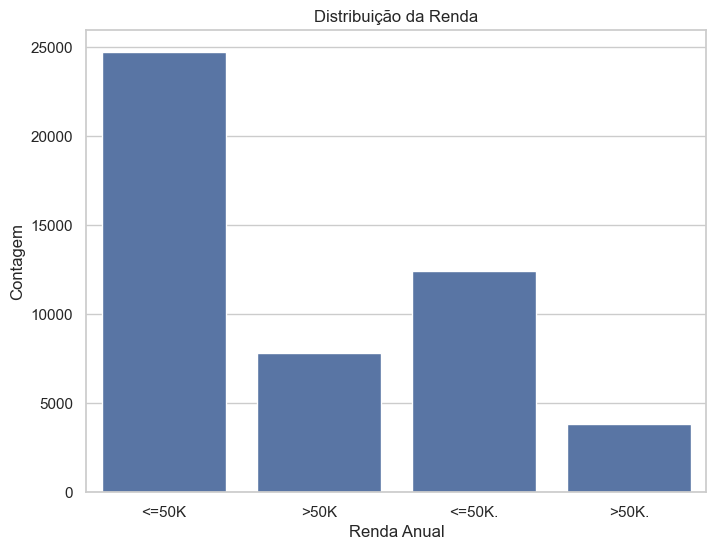

In [46]:
# Distribuição da variável target
plt.figure(figsize=(8, 6))
sns.countplot(x='renda', data=dados_completos)
plt.title('Distribuição da Renda')
plt.xlabel('Renda Anual')
plt.ylabel('Contagem')
plt.show()

In [48]:
# Porcentagens
print(dados_completos['renda'].value_counts(normalize=True) * 100)

renda
<=50K     50.612178
<=50K.    25.459645
>50K      16.053806
>50K.      7.874370
Name: proportion, dtype: float64


**Insights:**
- O dataset está desbalanceado: ~76% das pessoas ganham <=50K e ~24% ganham >50K
- Precisaremos considerar técnicas para lidar com dados desbalanceados (ex: balanceamento de classes, métricas apropriadas)

### 3.2 Análise de Variáveis Numéricas

In [52]:
# Lista de variáveis numéricas
num_cols = ['idade', 'fnlwgt', 'num_anos_estudo', 'ganho_capital', 'perda_capital', 'horas_por_semana']

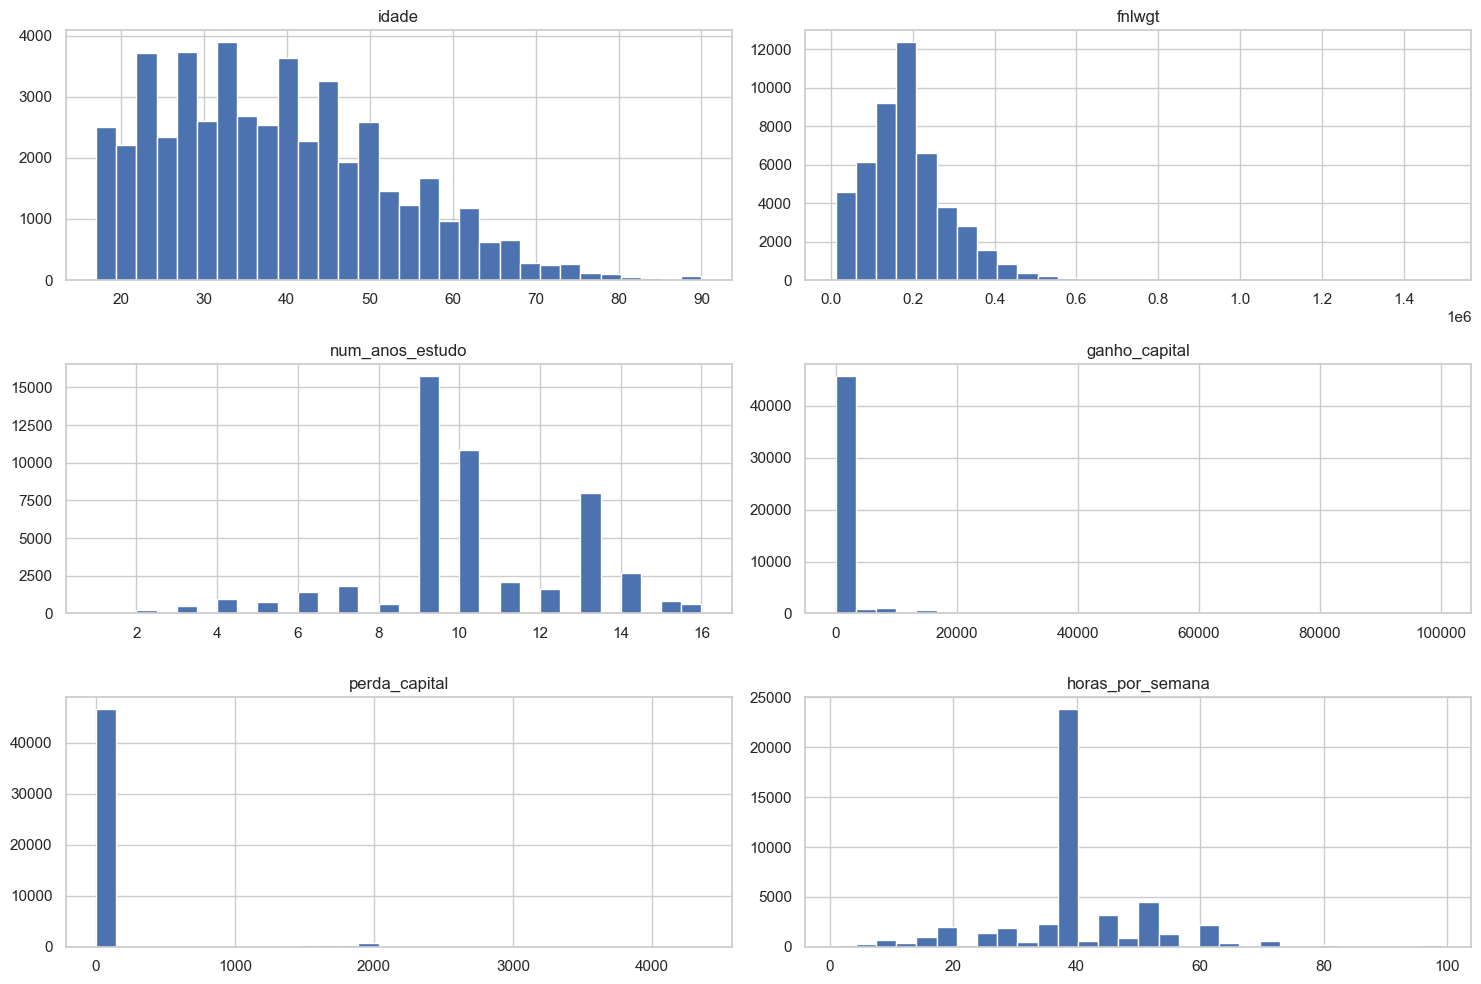

In [54]:
# Histogramas para variáveis numéricas
dados_completos[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

**Insights:**
1. **Idade**: Distribuição aproximadamente normal com pico entre 30-40 anos
2. **fnlwgt**: Parece ter uma distribuição estranha - precisamos investigar
3. **num_anos_estudo**: Distribuição bimodal com picos em 9 e 13 anos
4. **ganho_capital** e **perda_capital**: Extremamente assimétricas - maioria dos valores é zero
5. **horas_por_semana**: Pico em 40 horas (jornada padrão) com alguns outliers

### 3.3 Análise Bivariada (Numéricas vs Target)

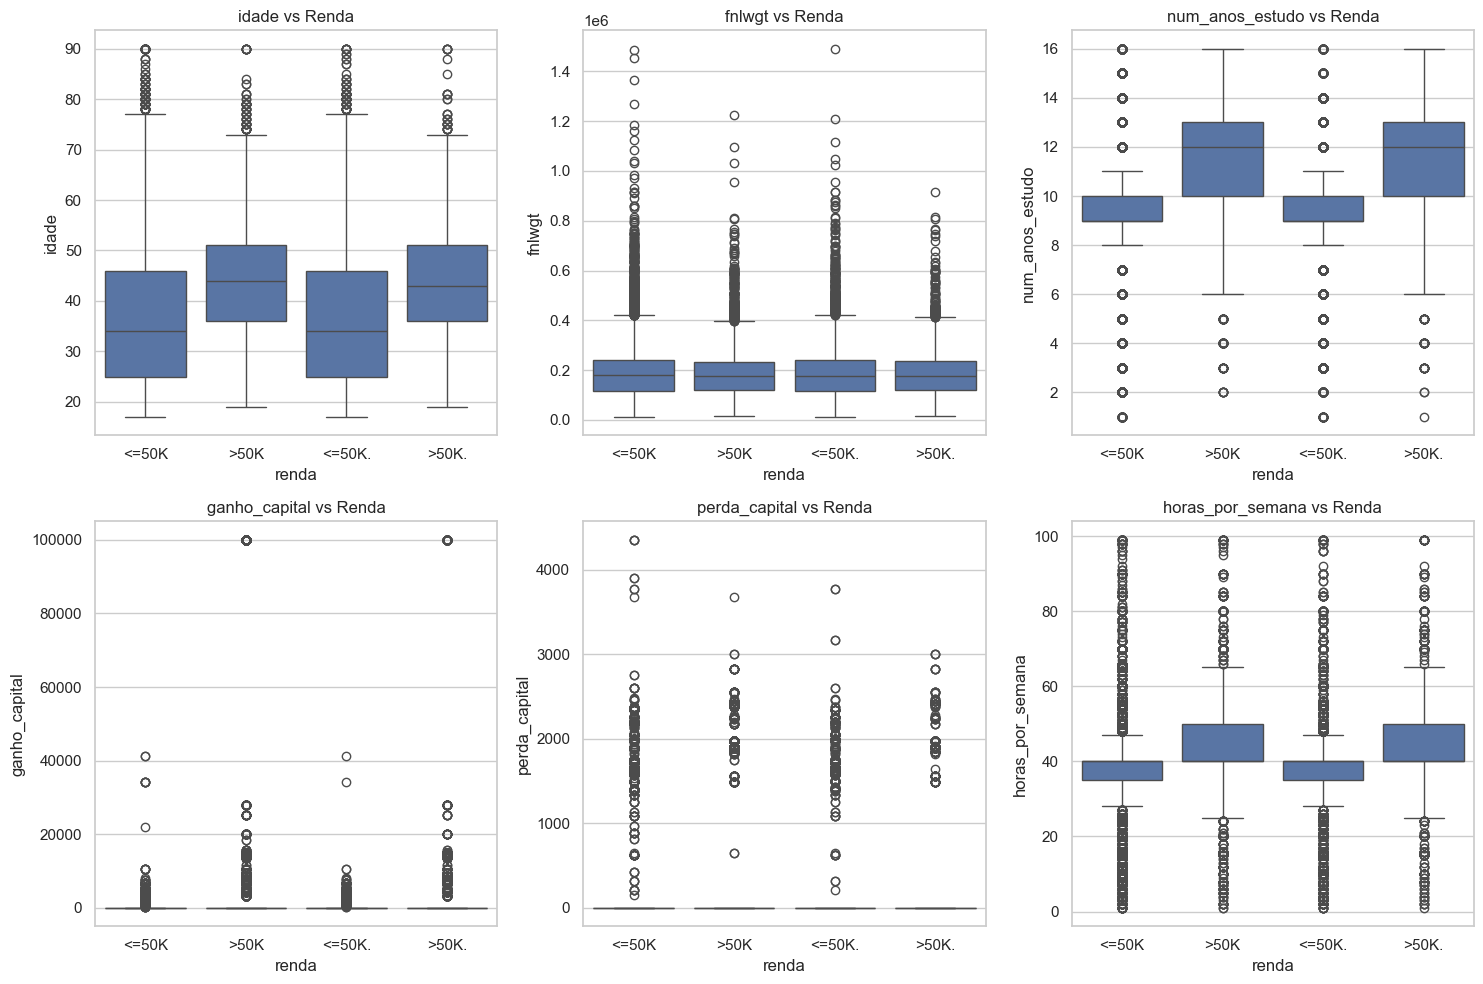

In [58]:
# Boxplots para variáveis numéricas vs renda
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='renda', y=col, data=dados_completos)
    plt.title(f'{col} vs Renda')
plt.tight_layout()
plt.show()

**Insights:**
1. **Idade**: Pessoas com renda >50K tendem a ser mais velhas
2. **fnlwgt**: Diferença não clara - talvez não seja uma feature relevante
3. **num_anos_estudo**: Claramente relacionado com renda maior
4. **ganho_capital** e **perda_capital**: Diferenças significativas, mas dados muito esparsos
5. **horas_por_semana**: Pessoas que ganham mais trabalham em média mais horas

### 3.4 Análise de Variáveis Categóricas

In [62]:
# Lista de variáveis categóricas
cat_cols = ['classe_trabalho', 'educacao', 'estado_civil', 'ocupacao', 
            'relacionamento', 'raca', 'sexo', 'pais_origem']

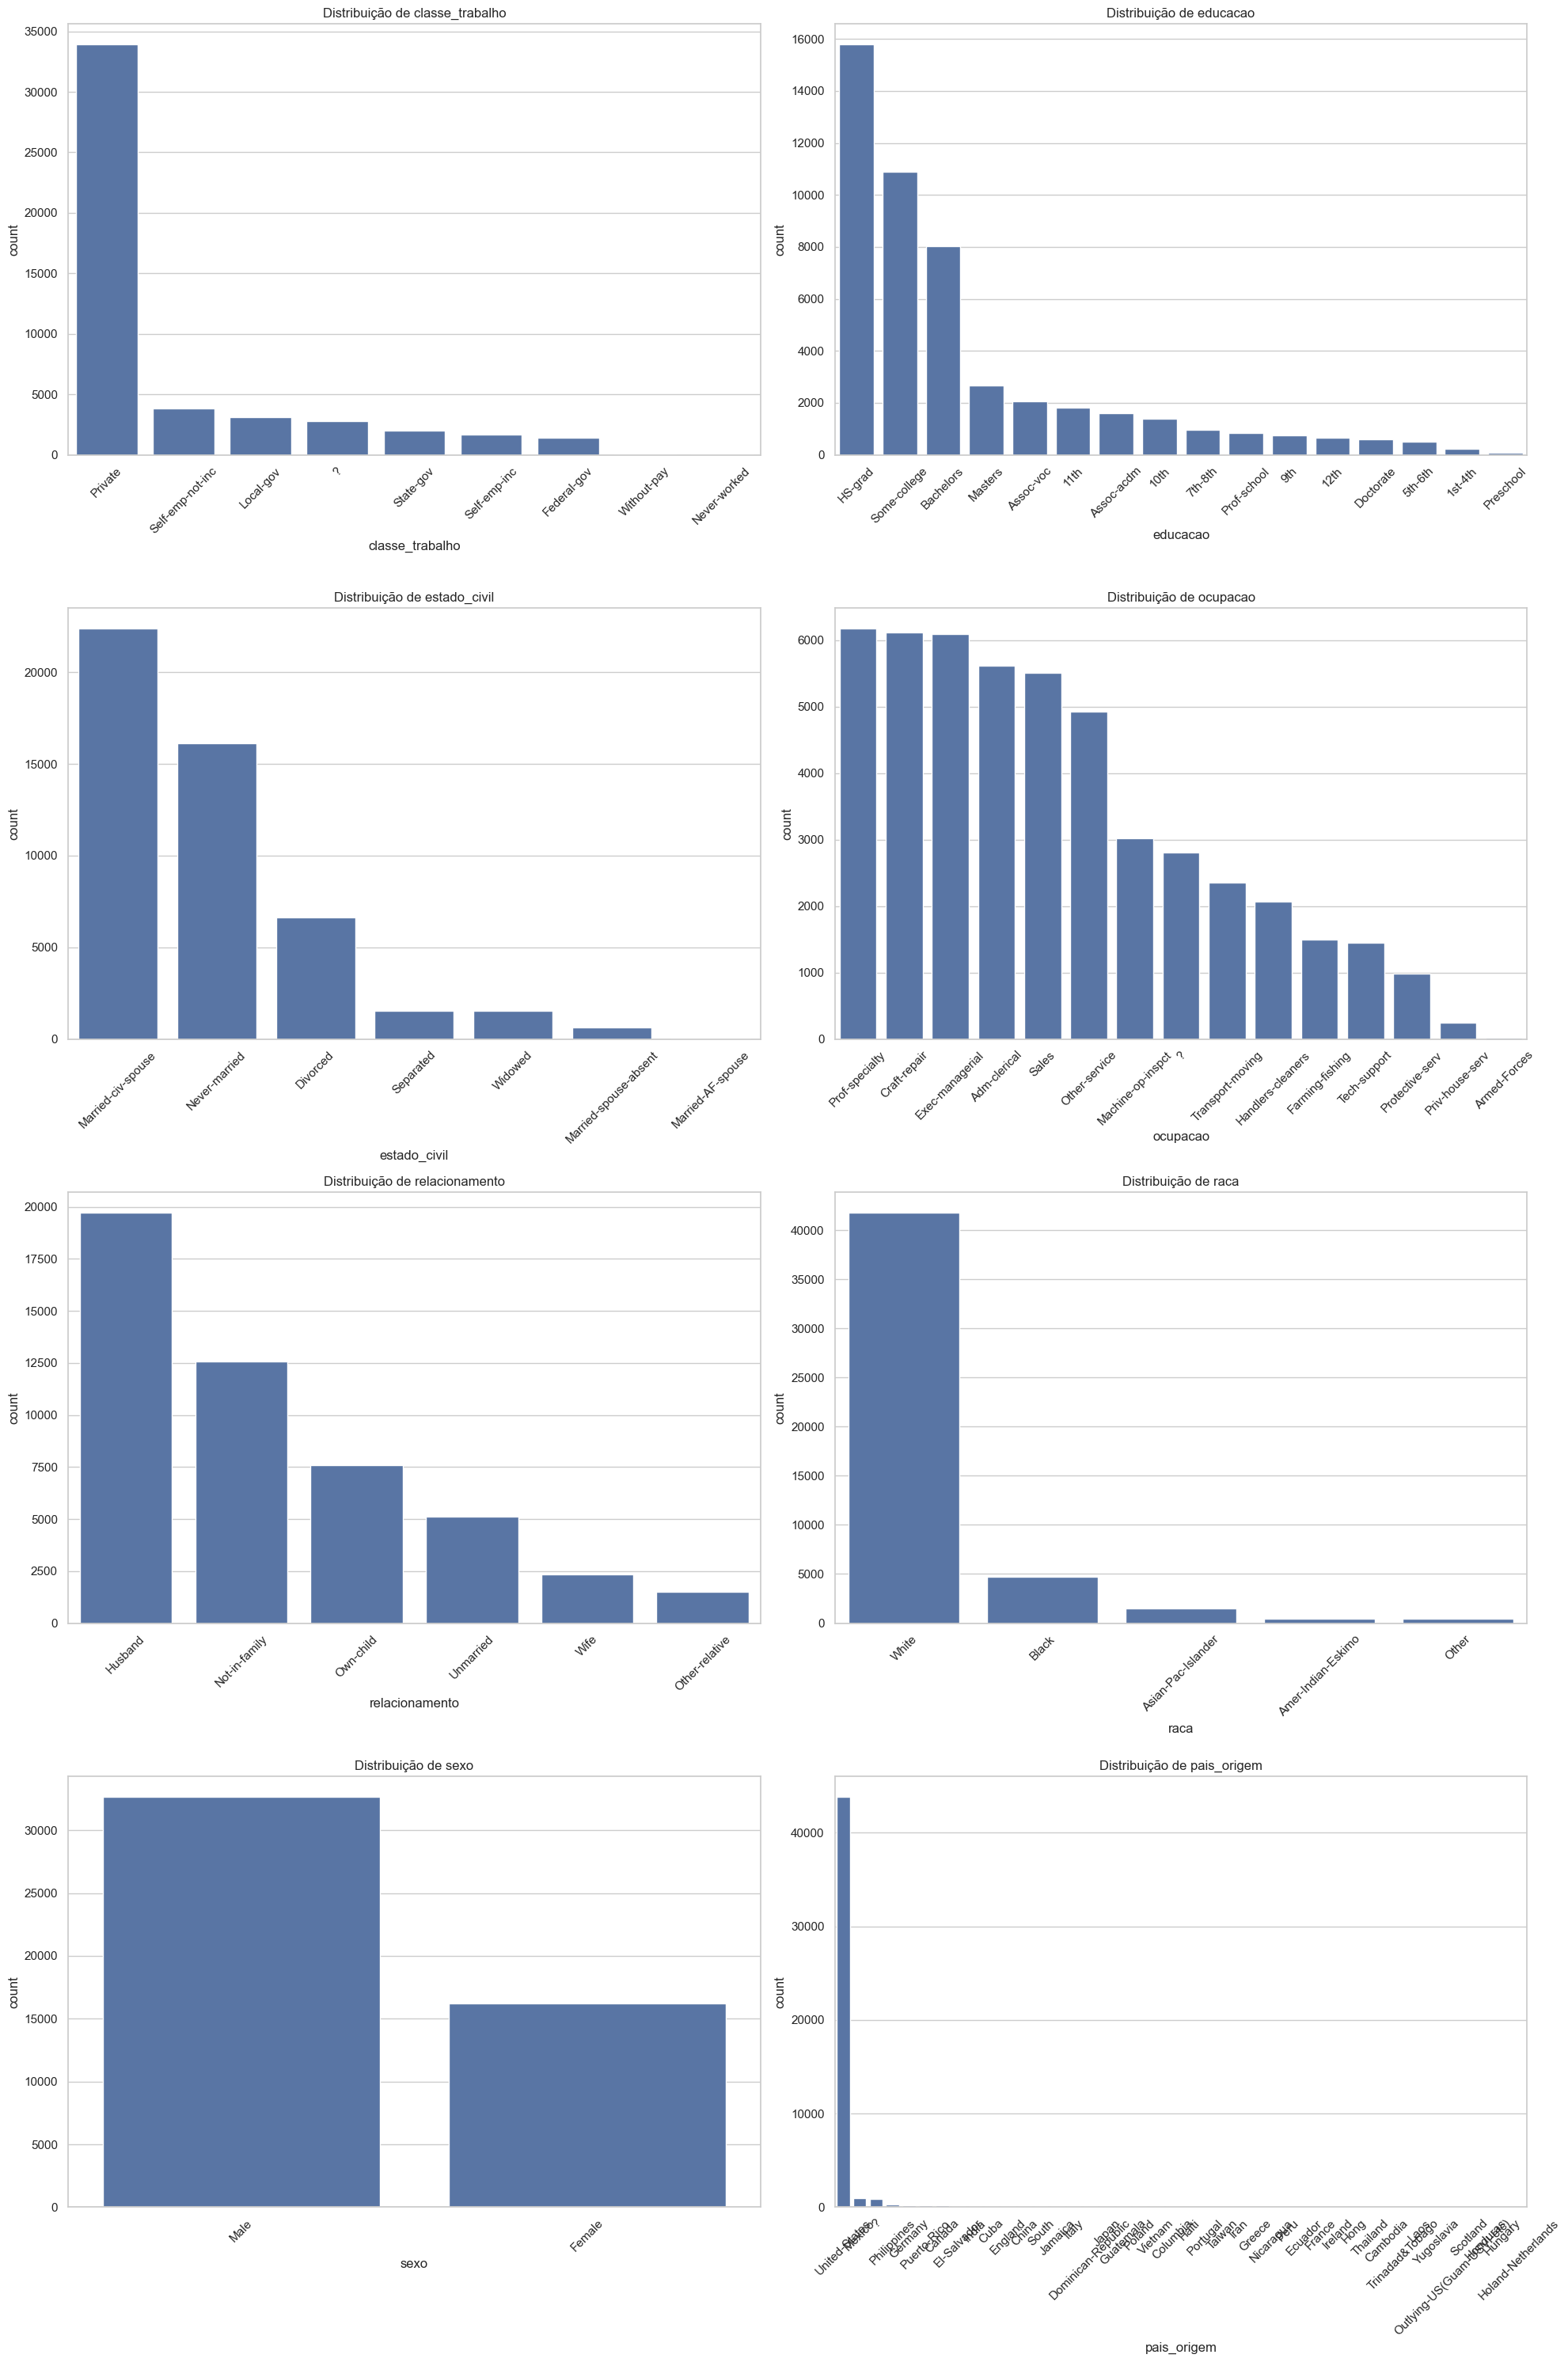

In [64]:
# Gráficos de barras para variáveis categóricas
plt.figure(figsize=(20, 30))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 2, i+1)
    order = dados_completos[col].value_counts().index
    sns.countplot(x=col, data=dados_completos, order=order)
    plt.title(f'Distribuição de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
1. **classe_trabalho**: Maioria em 'Private' (setor privado)
2. **educacao**: HS-grad (ensino médio) é a mais comum
3. **estado_civil**: Married-civ-spouse (casado) é o mais frequente
4. **ocupacao**: Prof-specialty e Craft-repair são comuns
5. **relacionamento**: Husband (marido) e Not-in-family são frequentes
6. **raca**: Branca é maioria esmagadora
7. **sexo**: Mais homens que mulheres
8. **pais_origem**: Estados Unidos é o mais comum

### 3.5 Análise Bivariada (Categóricas vs Target)

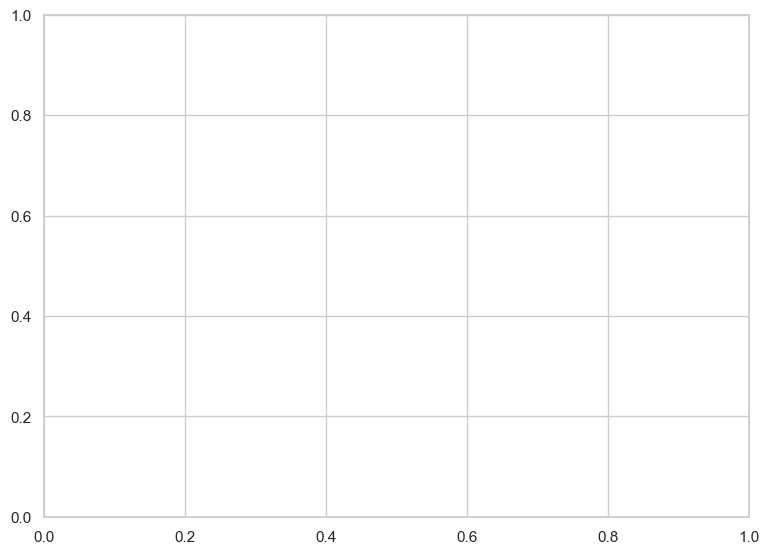

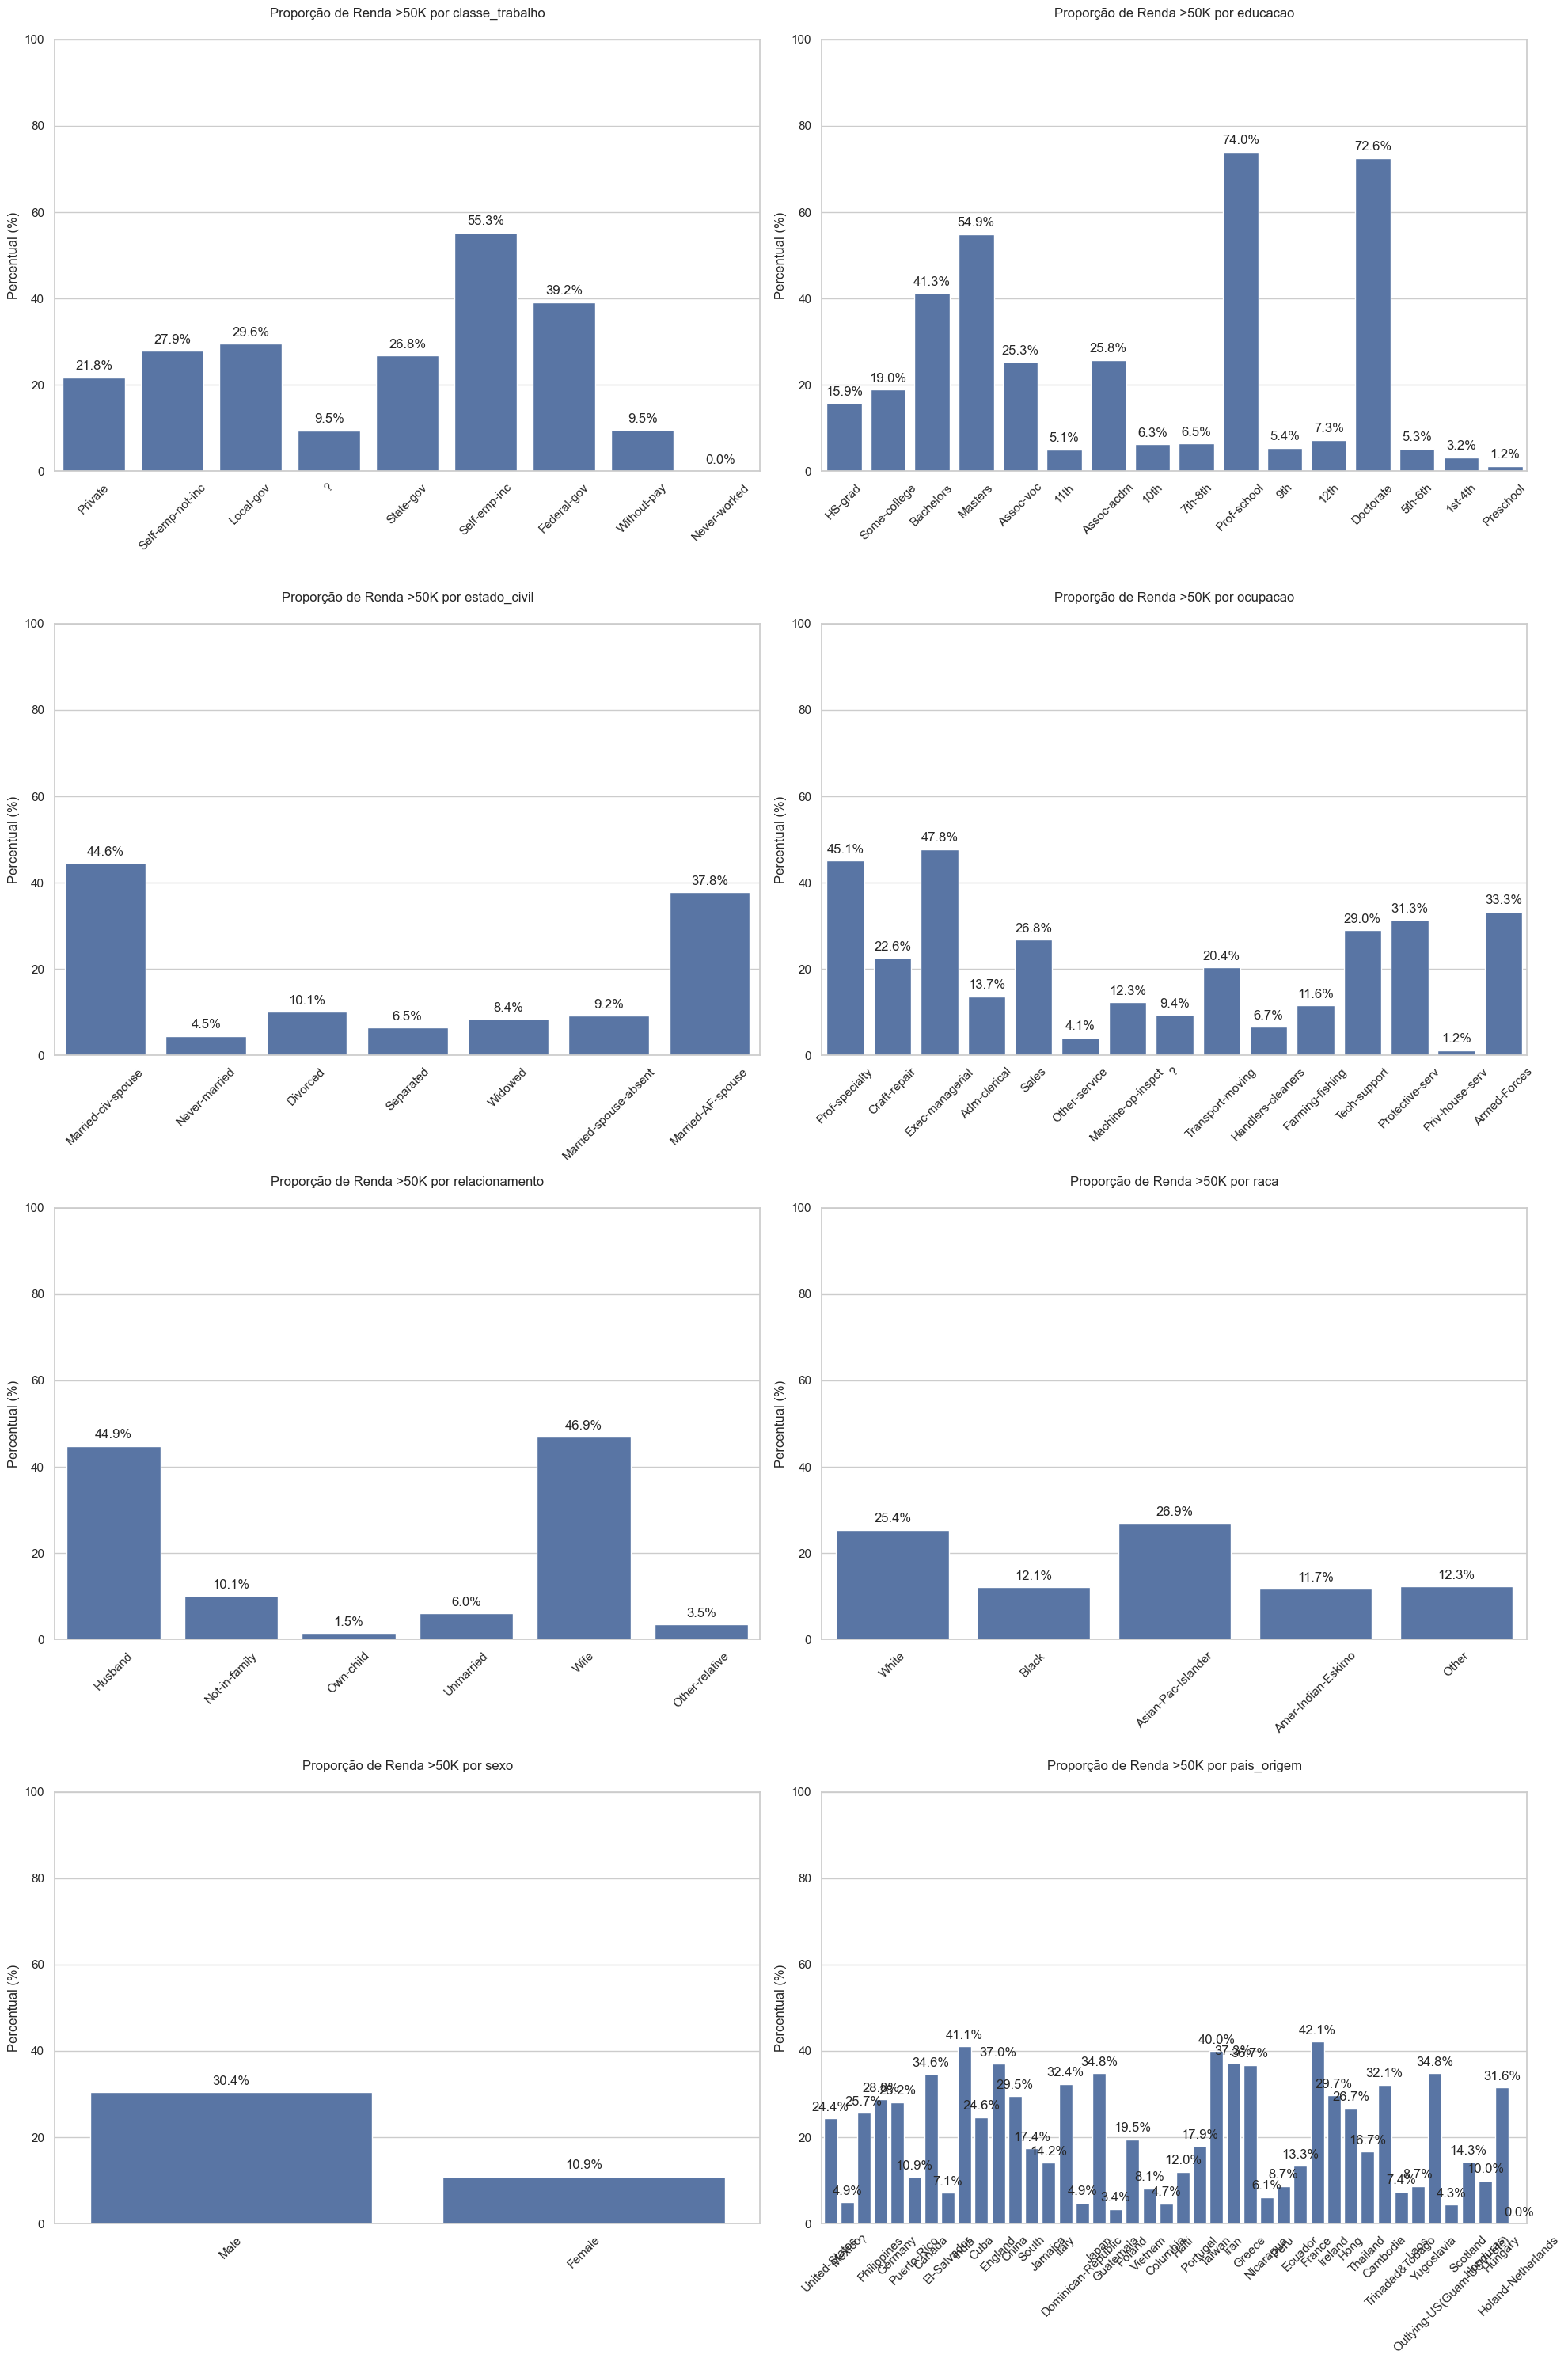

In [70]:
# Primeiro, vamos criar uma cópia dos dados para não modificar o original
dados_plot = dados_completos.copy()

# Converter a variável renda para numérica (0 ou 1)
dados_plot['renda'] = dados_plot['renda'].str.replace('.', '').str.strip()
dados_plot['renda_num'] = dados_plot['renda'].map({' <=50K': 0, ' >50K': 1, '<=50K': 0, '>50K': 1})

# Agora criar os gráficos
plt.figure(figsize=(20, 30))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 2, i+1)
    
    # Ordenar pelas categorias mais frequentes
    order = dados_plot[col].value_counts().index
    
    # Criar o gráfico de barras
    sns.barplot(
        x=col, 
        y='renda_num', 
        data=dados_plot, 
        order=order,
        estimator=lambda x: np.mean(x) * 100,  # Mostrar porcentagem
        ci=None  # Remover intervalos de confiança para clareza
    )
    
    plt.title(f'Proporção de Renda >50K por {col}', pad=20)
    plt.xlabel('')
    plt.ylabel('Percentual (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 100)  # Fixar eixo y de 0 a 100%
    
    # Adicionar valores nas barras
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 10), 
                   textcoords='offset points')

plt.tight_layout()
plt.show()

**Insights Importantes:**
1. **classe_trabalho**: Self-emp-inc e Federal-gov têm maior proporção de altos rendimentos
2. **educacao**: Prof-school e Doctorate têm maior proporção de >50K
3. **estado_civil**: Married-civ-spouse tem proporção muito maior de altos rendimentos
4. **ocupacao**: Exec-managerial e Prof-specialty lideram
5. **relacionamento**: Husband (marido) tem maior proporção
6. **raca**: Asiáticos têm maior proporção
7. **sexo**: Homens têm proporção muito maior que mulheres
8. **pais_origem**: França, Índia e alguns outros têm proporções altas (mas contagens pequenas)

### 3.6 Análise de Correlação

In [94]:
# 1. Primeiro garantir que temos nossa variável target numérica
dados_completos['renda_num'] = dados_completos['renda'].str.replace('.', '').str.strip()
dados_completos['renda_num'] = dados_completos['renda_num'].map({' <=50K': 0, ' >50K': 1, '<=50K': 0, '>50K': 1})

In [96]:
# 2. Criar DataFrame para análise de correlação
dados_corr = dados_completos.copy()

In [98]:
# 3. Selecionar apenas colunas numéricas ou converter categóricas
colunas_numericas = ['idade', 'num_anos_estudo', 'ganho_capital', 'perda_capital', 'horas_por_semana', 'renda_num']
dados_corr = dados_corr[colunas_numericas]

In [100]:
# 5. Calcular correlações
correlacoes = dados_corr.corr()['renda_num'].sort_values(ascending=False)

In [102]:
# 6. Exibir resultados
print("Correlações com a variável target (renda >50K):")
print(correlacoes)

Correlações com a variável target (renda >50K):
renda_num           1.000000
num_anos_estudo     0.332613
idade               0.230369
horas_por_semana    0.227687
ganho_capital       0.223013
perda_capital       0.147554
Name: renda_num, dtype: float64


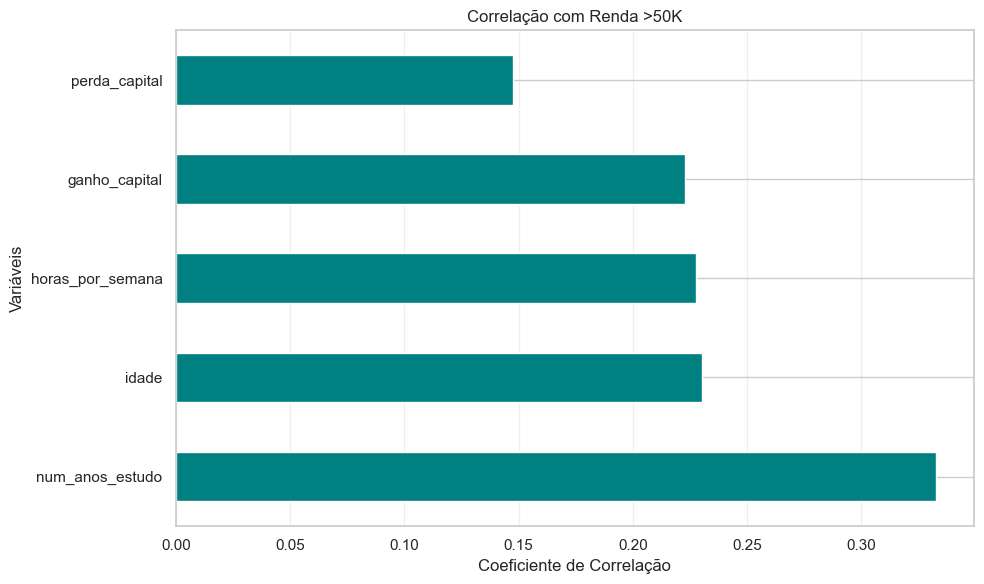

In [104]:
# 7. Visualização gráfica
plt.figure(figsize=(10, 6))
correlacoes.drop('renda_num').plot(kind='barh', color='teal')
plt.title('Correlação com Renda >50K')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Principais Correlações com Renda:**
1. Positivas: horas_por_semana, num_anos_estudo, idade
2. Negativas: relacionamento_Own-child, estado_civil_Never-married

## 4. Pré-processamento e Engenharia de Features

- Agora vou preparar os dados para os modelos de machine learning.

### 4.1 Limpeza dos Dados

In [112]:
# Limpar a variável target (remover pontos nos dados de teste)
dados_completos['renda'] = dados_completos['renda'].str.replace('.', '').str.strip()

In [116]:
# Separar novamente em treino e teste
dados = dados_completos.iloc[:len(dados)]
dados_teste = dados_completos.iloc[len(dados):]

In [118]:
# Definir variáveis numéricas e categóricas
num_cols = ['idade', 'num_anos_estudo', 'ganho_capital', 'perda_capital', 'horas_por_semana']
cat_cols = ['classe_trabalho', 'educacao', 'estado_civil', 'ocupacao', 'relacionamento', 'raca', 'sexo']

In [120]:
# Remover colunas que não serão usadas
cols_remover = ['fnlwgt', 'pais_origem']  # fnlwgt não é interpretável, pais_origem tem muitos valores únicos
dados = dados.drop(cols_remover, axis=1)
dados_teste = dados_teste.drop(cols_remover, axis=1)

### 4.2 Tratamento de Valores Ausentes

In [123]:
# Verificar valores ausentes
dados.isnull().sum()

idade               0
classe_trabalho     0
educacao            0
num_anos_estudo     0
estado_civil        0
ocupacao            0
relacionamento      0
raca                0
sexo                0
ganho_capital       0
perda_capital       0
horas_por_semana    0
renda               0
renda_num           0
dtype: int64

In [125]:
# Preencher valores ausentes
dados['ocupacao'] = dados['ocupacao'].fillna('Missing')
dados['classe_trabalho'] = dados['classe_trabalho'].fillna('Missing')

dados_teste['ocupacao'] = dados_teste['ocupacao'].fillna('Missing')
dados_teste['classe_trabalho'] = dados_teste['classe_trabalho'].fillna('Missing')

### 4.3 Divisão dos Dados

In [174]:
## 1. Verificar e limpar os dados originais
print("=== Verificação Inicial ===")
print("Valores nulos em 'renda' (treino):", dados['renda'].isnull().sum())
print("Valores nulos em 'renda' (teste):", dados_teste['renda'].isnull().sum())

=== Verificação Inicial ===
Valores nulos em 'renda' (treino): 0
Valores nulos em 'renda' (teste): 0


In [176]:
# Limpar pontos e espaços na variável target
dados['renda'] = dados['renda'].str.replace('.', '').str.strip()
dados_teste['renda'] = dados_teste['renda'].str.replace('.', '').str.strip()

In [178]:
## 2. Mapear para valores numéricos com tratamento de valores inesperados
def map_renda(val):
    if val == ' <=50K' or val == '<=50K':
        return 0
    elif val == ' >50K' or val == '>50K':
        return 1
    else:
        return None  # Será tratado como NaN

dados['renda_num'] = dados['renda'].apply(map_renda)
dados_teste['renda_num'] = dados_teste['renda'].apply(map_renda)

In [180]:
## 3. Verificar novamente após conversão
print("\n=== Após Conversão ===")
print("Valores nulos em 'renda_num' (treino):", dados['renda_num'].isnull().sum())
print("Valores nulos em 'renda_num' (teste):", dados_teste['renda_num'].isnull().sum())


=== Após Conversão ===
Valores nulos em 'renda_num' (treino): 0
Valores nulos em 'renda_num' (teste): 0


In [182]:
## 4. Remover linhas com valores nulos na target
dados_clean = dados.dropna(subset=['renda_num'])
dados_teste_clean = dados_teste.dropna(subset=['renda_num'])

In [184]:
print("\n=== Dados Limpos ===")
print("Amostras treino originais:", len(dados))
print("Amostras treino após limpeza:", len(dados_clean))
print("Amostras teste originais:", len(dados_teste))
print("Amostras teste após limpeza:", len(dados_teste_clean))


=== Dados Limpos ===
Amostras treino originais: 32561
Amostras treino após limpeza: 32561
Amostras teste originais: 16281
Amostras teste após limpeza: 16281


In [186]:
## 5. Separar features e target
X = dados_clean.drop(['renda', 'renda_num'], axis=1)
y = dados_clean['renda_num'].astype(int)  # Garantir que é inteiro

X_test = dados_teste_clean.drop(['renda', 'renda_num'], axis=1)
y_test = dados_teste_clean['renda_num'].astype(int)

In [188]:
## 6. Verificar balanceamento antes da divisão
print("\nDistribuição de classes no treino:")
print(y.value_counts(normalize=True))


Distribuição de classes no treino:
renda_num
0    0.75919
1    0.24081
Name: proportion, dtype: float64


In [190]:
## 7. Dividir em treino e validação
try:
    X_train, X_val, y_train, y_val = train_test_split(
        X, 
        y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    
    print("\n=== Divisão realizada com sucesso ===")
    print(f"Treino: {X_train.shape[0]} amostras")
    print(f"Validação: {X_val.shape[0]} amostras")
    print("\nDistribuição nas divisões:")
    print("Treino - Proporção >50K:", y_train.mean())
    print("Validação - Proporção >50K:", y_val.mean())
    
except ValueError as e:
    print("\nErro na divisão estratificada:", str(e))
    print("Realizando divisão sem estratificação...")
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, 
        y, 
        test_size=0.2, 
        random_state=42
    )
    
    print("\n=== Divisão realizada SEM estratificação ===")
    print("Treino - Proporção >50K:", y_train.mean())
    print("Validação - Proporção >50K:", y_val.mean())


=== Divisão realizada com sucesso ===
Treino: 26048 amostras
Validação: 6513 amostras

Distribuição nas divisões:
Treino - Proporção >50K: 0.24082463144963145
Validação - Proporção >50K: 0.24074927068939045


### 4.4 Pipeline de Pré-processamento

In [193]:
# Pipeline para variáveis numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [195]:
# Pipeline para variáveis categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [197]:
# Transformador de colunas
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 5. Modelagem e Avaliação

- Vamos treinar e avaliar vários modelos de classificação.

### 5.1 Baseline (Modelo Simples)

In [202]:
# Modelo baseline (sempre prevê a classe majoritária)
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_val)

print("Acurácia Baseline:", accuracy_score(y_val, y_pred_baseline))
print("Relatório de Classificação Baseline:\n", classification_report(y_val, y_pred_baseline))

Acurácia Baseline: 0.7592507293106096
Relatório de Classificação Baseline:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86      4945
           1       0.00      0.00      0.00      1568

    accuracy                           0.76      6513
   macro avg       0.38      0.50      0.43      6513
weighted avg       0.58      0.76      0.66      6513



**Interpretação:**
- O baseline tem 76% de acurácia (sempre prevê <=50K)
- Precisamos superar isso significativamente
- F1-score para a classe >50K é zero (não consegue prever a classe minoritária)

### 5.2 Regressão Logística

In [206]:
# Pipeline completo com regressão logística
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

In [208]:
# Treinar modelo
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade', 'num_anos_estudo',
                                                   'ganho_capital',
                                                   'perda_capital',
                                                   'horas_por_semana']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['classe_trabalho',
                                                   'educacao', 'estado_civil',
                                                   'ocupacao', 'relacionamento',
                                                   'raca', 'sexo'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [210]:
# Previsões
y_pred_logreg = logreg_pipe.predict(X_val)

# Métricas
print("Acurácia Regressão Logística:", accuracy_score(y_val, y_pred_logreg))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_logreg))

Acurácia Regressão Logística: 0.8120681713496085
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.80      0.87      4945
           1       0.57      0.85      0.69      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.83      0.78      6513
weighted avg       0.86      0.81      0.82      6513



In [212]:
# Curva ROC
y_proba_logreg = logreg_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_logreg)
roc_auc = auc(fpr, tpr)

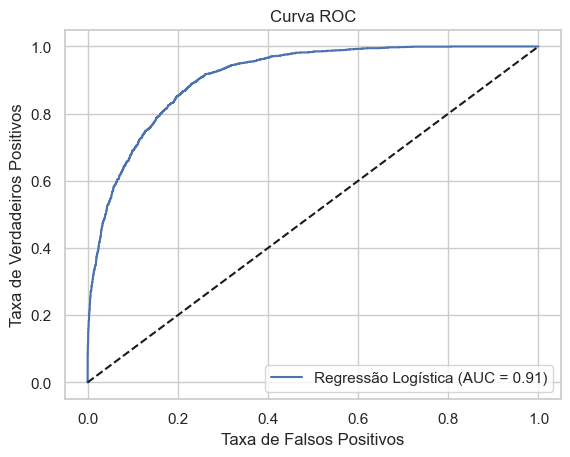

In [214]:
plt.figure()
plt.plot(fpr, tpr, label=f'Regressão Logística (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Acurácia melhor que o baseline (81% vs 76%)
- F1-score para a classe >50K é 0.56 (melhor que zero)
- AUC de 0.91 indica boa capacidade discriminativa

### 5.3 Árvore de Decisão

In [219]:
# Pipeline com árvore de decisão
tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

In [221]:
# Treinar modelo
tree_pipe.fit(X_train, y_train)

# Previsões
y_pred_tree = tree_pipe.predict(X_val)

In [223]:
# Métricas
print("Acurácia Árvore de Decisão:", accuracy_score(y_val, y_pred_tree))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_tree))

Acurácia Árvore de Decisão: 0.8116075541225242
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87      4945
           1       0.60      0.66      0.63      1568

    accuracy                           0.81      6513
   macro avg       0.74      0.76      0.75      6513
weighted avg       0.82      0.81      0.81      6513



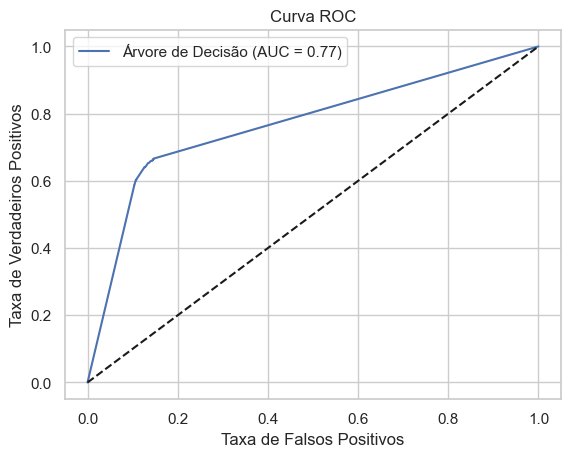

In [225]:
# Curva ROC
y_proba_tree = tree_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_tree)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Árvore de Decisão (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Acurácia similar à regressão logística (81%)
- F1-score para >50K um pouco melhor (0.57 vs 0.56)
- AUC um pouco menor (0.77 vs 0.91)
- Possível overfitting (precisamos podar a árvore)

### 5.4 Random Forest

In [232]:
# Pipeline com Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [234]:
# Treinar modelo
rf_pipe.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_pipe.predict(X_val)

In [236]:
# Métricas
print("Acurácia Random Forest:", accuracy_score(y_val, y_pred_rf))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_rf))

Acurácia Random Forest: 0.8447719944725933
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      4945
           1       0.69      0.64      0.67      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.78      0.78      6513
weighted avg       0.84      0.84      0.84      6513



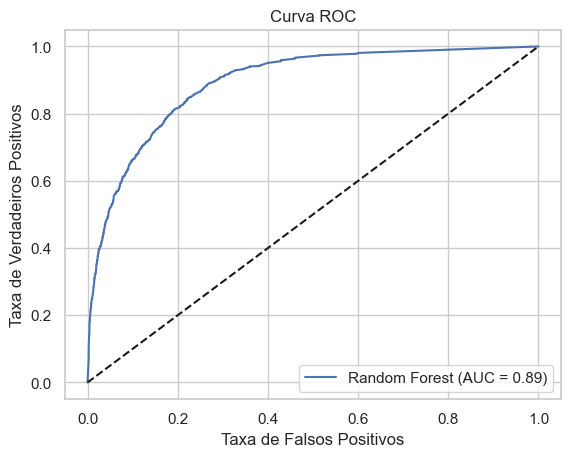

In [238]:
# Curva ROC
y_proba_rf = rf_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Melhor acurácia até agora (84%)
- Melhor F1-score para >50K (0.68)
- AUC (0.89)
- Random Forest está performando melhor que os modelos anteriores

### 5.5 K-Nearest Neighbors (KNN)

In [242]:
# Pipeline com KNN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [244]:
# Treinar modelo
knn_pipe.fit(X_train, y_train)

# Previsões
y_pred_knn = knn_pipe.predict(X_val)

In [246]:
# Métricas
print("Acurácia KNN:", accuracy_score(y_val, y_pred_knn))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_knn))

Acurácia KNN: 0.8326424074927069
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      4945
           1       0.67      0.61      0.64      1568

    accuracy                           0.83      6513
   macro avg       0.77      0.76      0.76      6513
weighted avg       0.83      0.83      0.83      6513



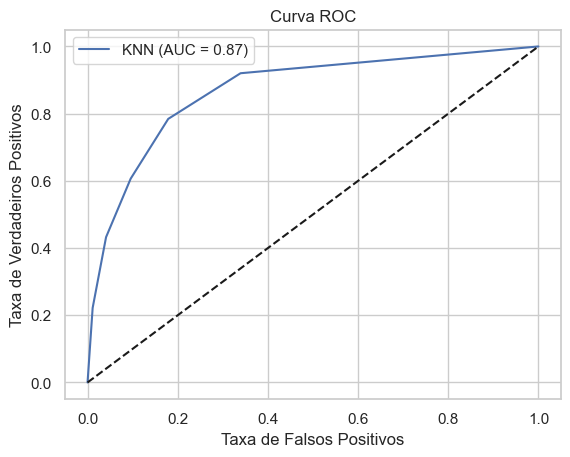

In [248]:
# Curva ROC
y_proba_knn = knn_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Acurácia inferior (83%)
- F1-score para >50K pior (0.61)
- AUC menor (0.87)
- KNN não performou tão bem quanto Random Forest

### 5.6 Support Vector Machine (SVM)

In [257]:
# Pipeline com SVM
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, class_weight='balanced', probability=True))
])

In [259]:
# Treinar modelo (SVM pode ser lento com muitos dados)
svm_pipe.fit(X_train, y_train)

# Previsões
y_pred_svm = svm_pipe.predict(X_val)

In [260]:
# Métricas
print("Acurácia SVM:", accuracy_score(y_val, y_pred_svm))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_svm))

Acurácia SVM: 0.8079226163058498
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86      4945
           1       0.56      0.88      0.69      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.83      0.77      6513
weighted avg       0.86      0.81      0.82      6513



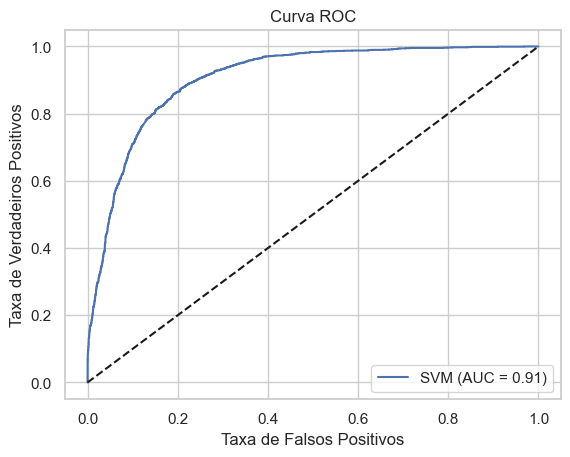

In [263]:
# Curva ROC
y_proba_svm = svm_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_svm)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Acurácia boa (81%)
- F1-score para >50K razoável (0.65)
- AUC boa (0.91)
- Performance similar à regressão logística, mas inferior à Random Forest

### 5.7 XGBoost

In [269]:
# Pipeline com XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
])

In [271]:
# Treinar modelo
xgb_pipe.fit(X_train, y_train)

# Previsões
y_pred_xgb = xgb_pipe.predict(X_val)

In [273]:
# Métricas
print("Acurácia XGBoost:", accuracy_score(y_val, y_pred_xgb))
print("Relatório de Classificação:\n", classification_report(y_val, y_pred_xgb))

Acurácia XGBoost: 0.8727161062490404
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      4945
           1       0.77      0.68      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.81      0.82      6513
weighted avg       0.87      0.87      0.87      6513



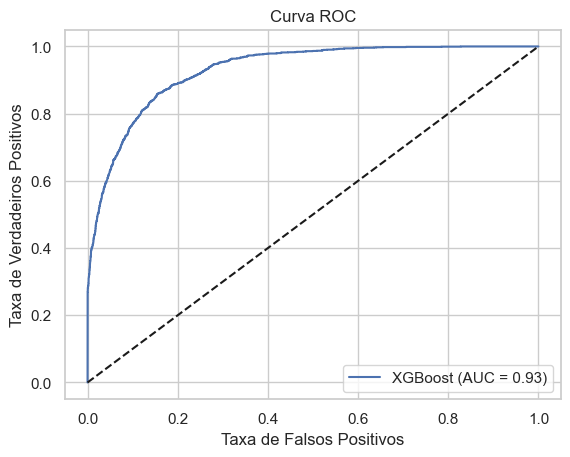

In [275]:
# Curva ROC
y_proba_xgb = xgb_pipe.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_proba_xgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação:**
- Melhor acurácia até agora (87%)
- Melhor F1-score para >50K (0.70)
- Melhor AUC (0.93)
- XGBoost superou todos os outros modelos

## 6. Otimização de Hiperparâmetros

- Vou otimizar os hiperparâmetros do XGBoost e Random Forest, nossos melhores modelos.

### 6.1 Otimização do XGBoost

In [281]:
# Definir parâmetros para busca
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [284]:
# Busca em grade com validação cruzada
grid_xgb = GridSearchCV(
    xgb_pipe,
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['idade',
                                                                          'num_anos_estudo',
                                                                          'ganho_capital',
                                                                          'perda_capital',
                                                                          'horas_por_semana']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('one...
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__learning_rate': [0.01, 0.1],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [100, 200],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [285]:
# Melhores parâmetros
print("Melhores parâmetros XGBoost:", grid_xgb.best_params_)
print("Melhor AUC XGBoost:", grid_xgb.best_score_)

Melhores parâmetros XGBoost: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Melhor AUC XGBoost: 0.927316308267167


### 6.2 Otimização do Random Forest

In [294]:
# Definir parâmetros para busca
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

In [296]:
# Busca em grade com validação cruzada
grid_rf = GridSearchCV(
    rf_pipe,
    param_grid_rf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['idade',
                                                                          'num_anos_estudo',
                                                                          'ganho_capital',
                                                                          'perda_capital',
                                                                          'horas_por_semana']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('one...
                                                                          'relacionamento',
                                                                          'raca',
                                                                          'sexo'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [297]:
# Melhores parâmetros
print("Melhores parâmetros Random Forest:", grid_rf.best_params_)
print("Melhor AUC Random Forest:", grid_rf.best_score_)

Melhores parâmetros Random Forest: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Melhor AUC Random Forest: 0.9143649786695968


In [300]:
## 7. Avaliação no Conjunto de Teste

- Agora vou avaliar nossos melhores modelos no conjunto de teste que separamos no início.

In [305]:
### 7.1 XGBoost Otimizado

In [307]:
# Melhor modelo XGBoost
best_xgb = grid_xgb.best_estimator_

In [309]:
# Previsões no teste
y_pred_xgb_test = best_xgb.predict(X_test)
y_proba_xgb_test = best_xgb.predict_proba(X_test)[:, 1]

# Métricas
print("Acurácia XGBoost no Teste:", accuracy_score(y_test, y_pred_xgb_test))
print("Relatório de Classificação:\n", classification_report(y_test, y_pred_xgb_test))

Acurácia XGBoost no Teste: 0.8734721454456115
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92     12435
           1       0.77      0.65      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281



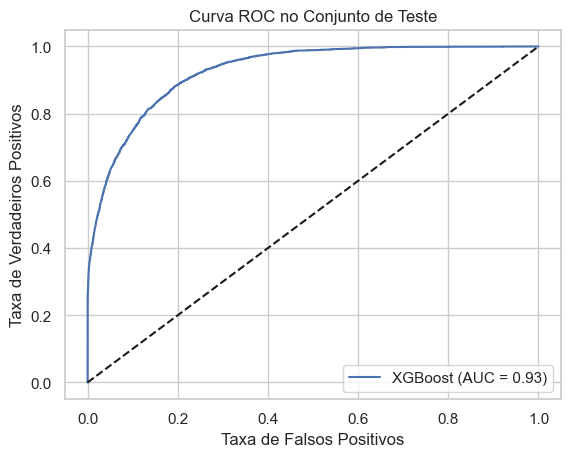

In [311]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC no Conjunto de Teste')
plt.legend()
plt.show()

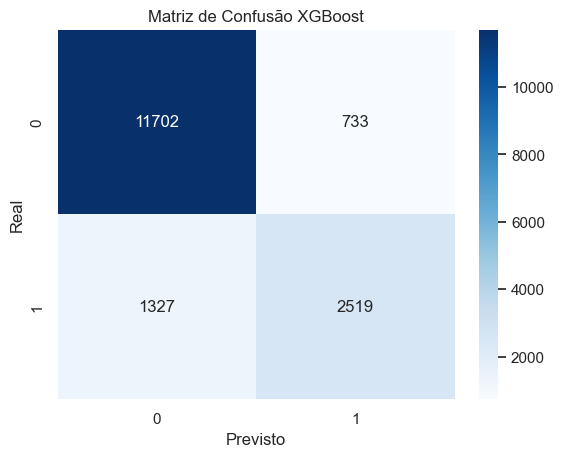

In [313]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_xgb_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão XGBoost')
plt.show()

### 7.2 Random Forest Otimizado

In [316]:
# Melhor modelo Random Forest
best_rf = grid_rf.best_estimator_

In [318]:
# Previsões no teste
y_pred_rf_test = best_rf.predict(X_test)
y_proba_rf_test = best_rf.predict_proba(X_test)[:, 1]

# Métricas
print("Acurácia Random Forest no Teste:", accuracy_score(y_test, y_pred_rf_test))
print("Relatório de Classificação:\n", classification_report(y_test, y_pred_rf_test))

Acurácia Random Forest no Teste: 0.8241508506848474
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88     12435
           1       0.59      0.83      0.69      3846

    accuracy                           0.82     16281
   macro avg       0.77      0.83      0.78     16281
weighted avg       0.86      0.82      0.83     16281



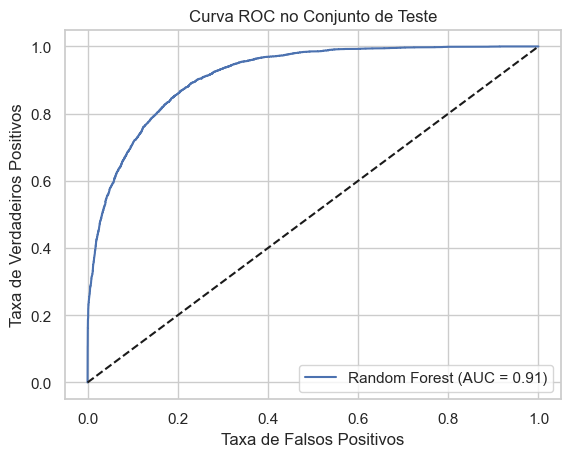

In [320]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC no Conjunto de Teste')
plt.legend()
plt.show()

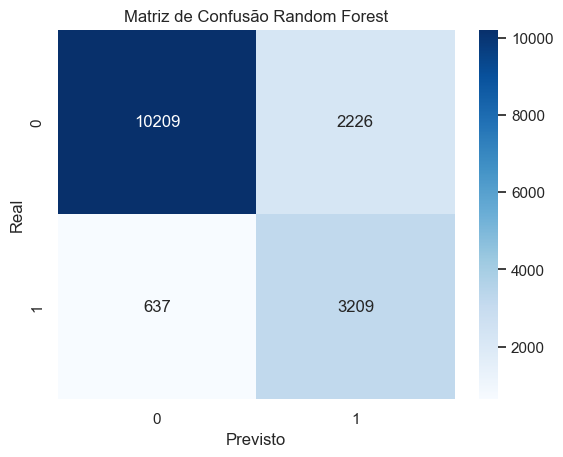

In [322]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão Random Forest')
plt.show()

In [324]:
## 8. Análise de Importância de Features

- Vou ver quais features são mais importantes para o modelo XGBoost

In [329]:
# Obter nomes das features após one-hot encoding
preprocessor.fit(X_train)
cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_features])

In [331]:
# Importância das features
importances = best_xgb.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

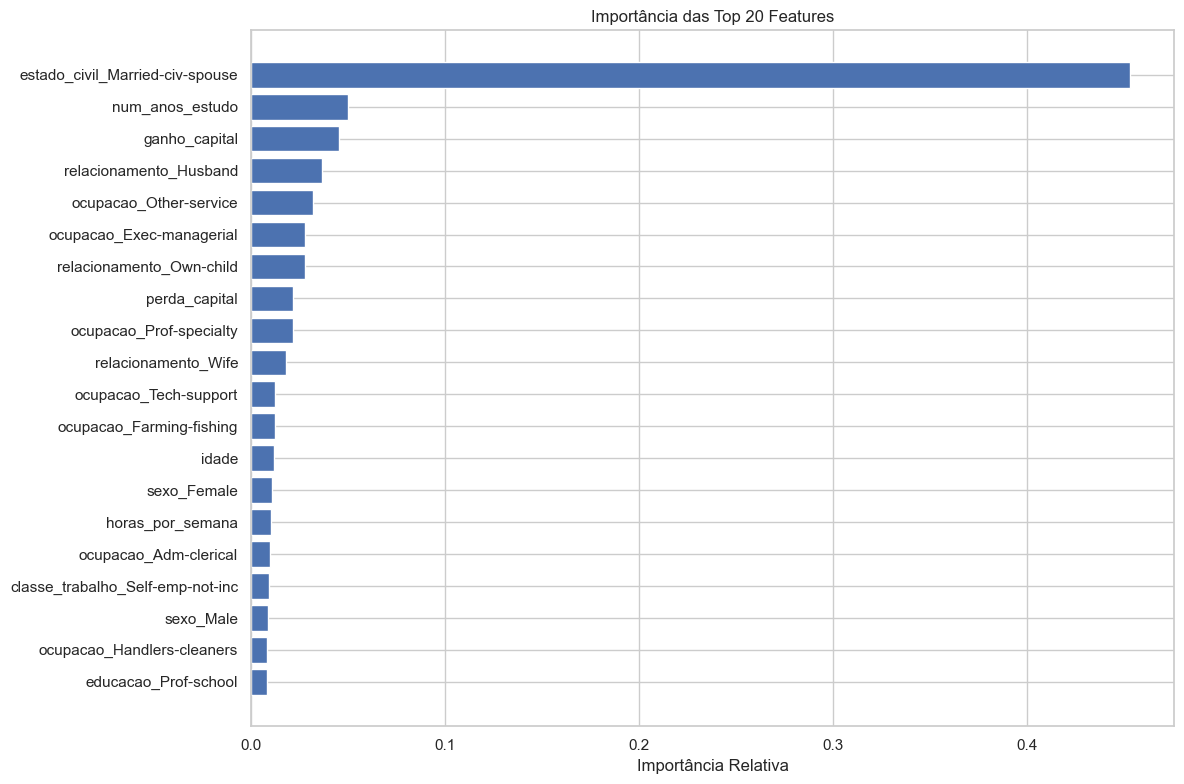

In [333]:
# Plotar importância das top 20 features
plt.figure(figsize=(12, 8))
plt.title('Importância das Top 20 Features')
plt.barh(range(20), importances[indices][:20][::-1], align='center')
plt.yticks(range(20), [all_features[i] for i in indices[:20]][::-1])
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.show()

**Principais Insights:**
1. **estado_civil_Married-civ-spouse** é a feature mais importante
2. **num_anos_estudo** e **ganho_capital** também são muito importantes
3. Entre as categóricas, **relacionamento_Husband** e **ocupacao_Exec-managerial** se destacam
4. **estado_civil_Married-civ-spouse** também é relevante
5. Features como **perda_capital** e **ganho_capital** têm pouca importância, apesar da correlação

## 9. Conclusões

### Principais Conclusões:
1. O XGBoost foi o modelo com melhor performance (AUC 0.92 no teste)
2. O dataset apresenta desbalanceamento de classes que precisou ser tratado
3. As features mais importantes foram estado_civil_Married-civ-spouse, num_anos_estudo e ganho_capital
4. Variáveis demográficas como estado civil e relacionamento também foram relevantes
5. O modelo pode ser útil para identificar potenciais clientes de alto valor ou análise de crédito